# TBWISA validation notebook for DIF-PI

This notebook validates the Scenario Generation (TBWISA) module used in the DIF-PI framework and separates its evaluation with the experiments from the paper “Generating and Optimizing What-If Scenarios Using a Transformers-Based Forecasting Model”.

## What this notebook does

1. loads the processed daily SKU panel used by DIF-PI;
2. reuses the saved `TEST_SKUs` split from the DIF-PI forecasting / executive workflow whenever that artifact is available;
3. loads the saved global Transformer forecaster or optionally trains it if the artifact is missing;
4. evaluates TBWISA against the benchmark scenario generators:
   - log-linear,
   - XGBoost;
5. measures forecast quality on the observable baseline continuation (*delta = 0*);
6. evaluates sensitivity to elasticity-estimation noise;
7. evaluates monotonicity consistency and economic plausibility across the intervention grid;
8. evaluates the stability of optimal windows across deltas and across models;
9. exports thesis-ready tables and figures for the TBWISA validation section.

## Input

- the processed daily panel created by `eda-complete-journey.ipynb`
- the saved global forecaster artifact directory from `train-forecaster.ipynb`
- the saved `test_skus.csv` split file from the DIF-PI workflow, when available

## Output

- `tbwisa_forecast_accuracy.csv`
- `tbwisa_noise_sensitivity.csv`
- `tbwisa_plausibility.csv`
- `tbwisa_window_stability.csv`
- supporting by-SKU diagnostic CSV files
- plots for accuracy, monotonicity, plausibility, implied elasticity, noise sensitivity, and window stability


In [1]:
from pathlib import Path
import json
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

from src.tbwisa import TBWISAGenerator
from src.loglinear_scenarios import LogLinearScenarioGeneration
from src.xgboost_scenarios import XGBoostScenarioGeneration
from src.transformer_forecaster import ScenarioGenerationTransformerForecaster

## Configuration

Update the paths below if your processed files or saved forecaster artifact live in a different location.

In [2]:
# Paths
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

PANEL_PATH = REPO_ROOT / "datasets" / "processed" / "difpi_pricing_demand_panel.csv"

FORECASTER_DIR_CANDIDATES = [
    REPO_ROOT / "artifacts" / "models" / "scenario_gen_transformer_global",
    REPO_ROOT / "artifacts" / "scenario_generation_transformer_artifact",
]
FORECASTER_DIR = FORECASTER_DIR_CANDIDATES[0]
TEST_SKUS_PATH_CANDIDATES = [p / "test_skus.csv" for p in FORECASTER_DIR_CANDIDATES]

OUT_DIR = REPO_ROOT / "artifacts" / "tbwisa_validation_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Column names
SKU_COL = "StockCode"
TIME_COL = "timestamp"
PRICE_COL = "price"
DEMAND_COL = "demand"

# Evaluation settings
DELTA_GRID = [-15, -10, -5, 0, 5, 10, 15]
HORIZON = 30
# HORIZON = 7
TRAIN_FRAC = 0.80
MAX_EVAL_SKUS = 100
MIN_HISTORY = 120      # minimum points needed to evaluate one SKU
MIN_WINDOW = 7
MAX_WINDOW = 30
LENGTH_PENALTY = 0.0

# Controlled TBWISA settings
TBWISA_CFG = dict(
    seasonal_periods=(7.0, 365.25),
    eps=1e-9,
    prior_eps=0.05,
    use_event=True,
    price_change_pct_thresh=0.01,
    huber_epsilon=1.35,
    huber_alpha=1e-4,
    min_fit_rows=30,
    elast_max_abs=5.0,
)

# Noise sensitivity
NOISE_LEVELS = [0.0, 0.01, 0.03, 0.05, 0.10]
NOISE_DELTA_FOR_EVAL = 0
NOISE_SEED = 42

## Utilities

In [3]:
def _daily_future_index(last_ts, horizon):
    last_ts = pd.to_datetime(last_ts)
    return pd.date_range(start=last_ts + pd.Timedelta(days=1), periods=horizon, freq='D')


def load_panel(panel_path: Path) -> pd.DataFrame:
    df = pd.read_csv(panel_path)
    df[TIME_COL] = pd.to_datetime(df[TIME_COL])
    df[SKU_COL] = df[SKU_COL].astype(str)
    df = df.sort_values([SKU_COL, TIME_COL]).reset_index(drop=True)
    return df


def get_eval_skus(panel_df: pd.DataFrame, max_eval_skus: int = 25, min_history: int = 120):
    stats = (
        panel_df.groupby(SKU_COL)
        .agg(
            n_points=(DEMAND_COL, "size"),
            active_days=(DEMAND_COL, lambda s: int((pd.Series(s) > 0).sum())),
            mean_demand=(DEMAND_COL, "mean"),
        )
        .reset_index()
    )
    stats[SKU_COL] = stats[SKU_COL].astype(str)
    stats = stats[stats["n_points"] >= int(min_history)].copy()
    stats = stats.sort_values(["active_days", "n_points", "mean_demand"], ascending=False)
    return stats.head(int(max_eval_skus))[SKU_COL].astype(str).tolist(), stats


def load_saved_test_skus(path_candidates):
    for p in path_candidates:
        if p.exists():
            try:
                df = pd.read_csv(p)
                first_col = df.columns[0]
                vals = df[first_col].astype(str).dropna().tolist()
                if len(vals):
                    return vals, p
            except Exception as exc:
                print(f"Could not read saved TEST_SKUs from {p}: {exc}")
    return None, None


def select_eval_skus(panel_df: pd.DataFrame, max_eval_skus: int = 25, min_history: int = 120):
    fallback_skus, stats = get_eval_skus(panel_df, max_eval_skus=max_eval_skus, min_history=min_history)

    saved_test_skus, saved_path = load_saved_test_skus(TEST_SKUS_PATH_CANDIDATES)
    if not saved_test_skus:
        print("Saved TEST_SKUs not found. Falling back to notebook-local SKU ranking.")
        return fallback_skus, stats, None

    eligible_stats = stats[stats[SKU_COL].astype(str).isin(saved_test_skus)].copy()
    if eligible_stats.empty:
        print(f"Saved TEST_SKUs found at {saved_path}, but none matched the current eligible panel. Falling back.")
        return fallback_skus, stats, saved_path

    eligible_stats = eligible_stats.sort_values(["active_days", "n_points", "mean_demand"], ascending=False)
    eval_skus = eligible_stats.head(int(max_eval_skus))[SKU_COL].astype(str).tolist()
    return eval_skus, eligible_stats, saved_path


def split_history_future(sku_df: pd.DataFrame, train_frac: float = 0.8, horizon: int = 7):
    sku_df = sku_df.sort_values(TIME_COL).reset_index(drop=True)
    n = len(sku_df)
    cut = max(int(np.floor(n * float(train_frac))), 60)
    cut = min(cut, n - int(horizon))
    hist = sku_df.iloc[:cut].copy()
    fut = sku_df.iloc[cut:cut + int(horizon)].copy()
    return hist, fut


def safe_mape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)))


def mae_rmse_mape(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": safe_mape(y_true, y_pred),
    }


def _resolve_forecaster_dir():
    for p in FORECASTER_DIR_CANDIDATES:
        if p.exists():
            return p
    return FORECASTER_DIR_CANDIDATES[0]


def load_or_train_forecaster(panel_df: pd.DataFrame):
    chosen_dir = _resolve_forecaster_dir()
    if chosen_dir.exists():
        try:
            model = ScenarioGenerationTransformerForecaster.load(str(chosen_dir))
            print(f"Loaded saved forecaster from: {chosen_dir}")
            return model
        except Exception as exc:
            print(f"Could not load saved forecaster from {chosen_dir}: {exc}. Training a temporary model instead...")

    train_skus, _ = get_eval_skus(panel_df, max_eval_skus=60, min_history=MIN_HISTORY)
    forecaster = ScenarioGenerationTransformerForecaster(
        sequence_length=30, size_layer=64, embedded_size=64,
        output_size=1, num_heads=8, dropout_rate=0.1
    )
    info = forecaster.fit_global(
        panel_df=panel_df,
        sku_col=SKU_COL,
        time_col=TIME_COL,
        target_col=DEMAND_COL,
        train_skus=train_skus,
        batch_size=64,
        epochs=10,
        learning_rate=1e-3,
        per_sku_train_frac=TRAIN_FRAC,
        min_points=60,
        verbose=0,
    )
    chosen_dir.mkdir(parents=True, exist_ok=True)
    forecaster.save(str(chosen_dir))
    print("Temporary forecaster training info:", info)
    return forecaster


def fit_tbwisa(hist_df: pd.DataFrame):
    gen = TBWISAGenerator()
    gen.configure_controlled_elasticity(**TBWISA_CFG)
    return gen


def fit_loglinear(hist_df: pd.DataFrame):
    gen = LogLinearScenarioGeneration()
    work = hist_df[[PRICE_COL, DEMAND_COL]].copy()
    work = work[(work[PRICE_COL] > 0) & (work[DEMAND_COL] > 0)]
    gen.train(work, PRICE_COL, DEMAND_COL)
    return gen


def fit_xgboost(hist_df: pd.DataFrame):
    gen = XGBoostScenarioGeneration()
    work = hist_df[[PRICE_COL, DEMAND_COL]].copy()
    work = work[(work[PRICE_COL] > 0) & (work[DEMAND_COL] > 0)]
    gen.train(work, PRICE_COL, DEMAND_COL)
    return gen


def _scenario_name(delta: int):
    return f"{PRICE_COL} change {delta}%"


def generate_scenarios_tbwisa(gen: TBWISAGenerator, hist_df: pd.DataFrame, deltas):
    inp, out = gen.generate_scenarios(hist_df[[PRICE_COL, DEMAND_COL]].copy(), PRICE_COL, DEMAND_COL, deltas)
    scenarios = {}
    for delta in deltas:
        name = _scenario_name(delta)
        scenarios[delta] = pd.DataFrame({
            TIME_COL: hist_df[TIME_COL].values,
            PRICE_COL: np.asarray(inp[name], float),
            DEMAND_COL: np.asarray(out[name], float),
        })
    return scenarios, getattr(gen, "_last_elasticity_meta", {})


def generate_scenarios_loglinear(gen: LogLinearScenarioGeneration, hist_df: pd.DataFrame, deltas):
    last_price = float(hist_df[PRICE_COL].iloc[-1])
    scenarios = {}
    for delta in deltas:
        adj_price = np.full(len(hist_df), last_price * (1.0 + float(delta) / 100.0))
        pred_log = gen.model.predict(np.log(adj_price).reshape(-1, 1))
        pred_dem = np.exp(pred_log)
        scenarios[delta] = pd.DataFrame({
            TIME_COL: hist_df[TIME_COL].values,
            PRICE_COL: adj_price,
            DEMAND_COL: pred_dem,
        })
    return scenarios, {}


def generate_scenarios_xgboost(gen: XGBoostScenarioGeneration, hist_df: pd.DataFrame, deltas):
    last_price = float(hist_df[PRICE_COL].iloc[-1])
    scenarios = {}
    for delta in deltas:
        adj_price = np.full(len(hist_df), last_price * (1.0 + float(delta) / 100.0))
        pred_log = gen.model.predict(np.log(adj_price).reshape(-1, 1))
        pred_dem = np.exp(pred_log)
        scenarios[delta] = pd.DataFrame({
            TIME_COL: hist_df[TIME_COL].values,
            PRICE_COL: adj_price,
            DEMAND_COL: pred_dem,
        })
    return scenarios, {}


def rollout_scenarios(forecaster, scenario_dict, horizon: int):
    rolled = {}
    for delta, scen_df in scenario_dict.items():
        hist_d = scen_df[DEMAND_COL].astype(float).values
        future_d = forecaster.forecast(hist_d, forecast_length=horizon)
        last_price = float(scen_df[PRICE_COL].iloc[-1])
        future_price = np.full(int(horizon), last_price)
        rolled[delta] = {
            "history_df": scen_df.copy(),
            "future_index": _daily_future_index(scen_df[TIME_COL].iloc[-1], horizon),
            "future_price": future_price,
            "future_demand": np.asarray(future_d, float),
            "future_revenue": future_price * np.asarray(future_d, float),
        }
    return rolled


def monotonicity_consistency(rolled_dict):
    deltas = sorted(rolled_dict)
    means = np.array([np.mean(rolled_dict[d]["future_demand"]) for d in deltas], float)
    if len(means) <= 1:
        return np.nan
    ok = np.diff(means) <= 1e-9  # demand should not increase when price delta increases
    return float(np.mean(ok))


def economic_plausibility(rolled_dict):
    deltas = sorted(rolled_dict)
    prices = np.array([np.mean(rolled_dict[d]["future_price"]) for d in deltas], float)
    demands = np.array([np.mean(rolled_dict[d]["future_demand"]) for d in deltas], float)
    if len(prices) < 2 or np.std(prices) == 0 or np.std(demands) == 0:
        return {"corr_price_demand": np.nan, "plausible": np.nan}
    corr = float(np.corrcoef(prices, demands)[0, 1])
    return {"corr_price_demand": corr, "plausible": float(corr < 0)}


def implied_elasticities(rolled_dict):
    deltas = sorted(rolled_dict)
    base_delta = 0 if 0 in rolled_dict else deltas[len(deltas)//2]
    base_price = np.mean(rolled_dict[base_delta]["future_price"])
    base_demand = np.mean(rolled_dict[base_delta]["future_demand"])
    rows = []
    for d in deltas:
        if d == base_delta:
            continue
        p = np.mean(rolled_dict[d]["future_price"])
        q = np.mean(rolled_dict[d]["future_demand"])
        if base_price <= 0 or base_demand <= 0 or p <= 0 or q <= 0:
            elast = np.nan
        else:
            elast = float((np.log(q) - np.log(base_demand)) / (np.log(p) - np.log(base_price)))
        rows.append({"delta": d, "implied_elasticity": elast})
    return pd.DataFrame(rows)


def evaluate_window_stability(rolled_dict, min_window=7, max_window=30, penalty=0.0):
    helper = TBWISAGenerator()
    rows = []
    for d, payload in rolled_dict.items():
        best = helper.best_window(payload["future_revenue"], min_len=min_window, max_len=max_window, length_penalty=penalty)
        rows.append({"delta": d, "start": best["start"], "end": best["end"], "length": best["len"], "avg_revenue": best["avg"], "score": best["score"]})
    df = pd.DataFrame(rows).sort_values("delta").reset_index(drop=True)
    if len(df) == 0:
        return df, {"start_std": np.nan, "length_std": np.nan, "score_std": np.nan, "best_delta": np.nan}
    best_row = df.loc[df["score"].idxmax()]
    summary = {
        "start_std": float(df["start"].std(ddof=0)),
        "length_std": float(df["length"].std(ddof=0)),
        "score_std": float(df["score"].std(ddof=0)),
        "best_delta": float(best_row["delta"]),
    }
    return df, summary


def evaluate_forecast_accuracy(rolled_dict, actual_future_df: pd.DataFrame, delta_for_eval: int = 0):
    delta = int(delta_for_eval)
    if delta not in rolled_dict:
        delta = sorted(rolled_dict)[0]
    pred = np.asarray(rolled_dict[delta]["future_demand"], float)
    true = actual_future_df[DEMAND_COL].astype(float).values[:len(pred)]
    return mae_rmse_mape(true, pred)


def tbwisa_noise_sensitivity(hist_df: pd.DataFrame, actual_future_df: pd.DataFrame, forecaster, deltas, noise_levels, seed=42):
    rng = np.random.default_rng(int(seed))
    rows = []
    helper = TBWISAGenerator()
    helper.configure_controlled_elasticity(**TBWISA_CFG)
    base = hist_df[[PRICE_COL, DEMAND_COL, TIME_COL]].copy().reset_index(drop=True)
    for sigma in noise_levels:
        noisy = base.copy()
        if sigma > 0:
            noisy_price = np.exp(
                np.log(np.clip(noisy[PRICE_COL].values.astype(float), 1e-9, None))
                + rng.normal(0.0, sigma, size=len(noisy))
            )
            noisy[PRICE_COL] = noisy_price
        scen, meta = generate_scenarios_tbwisa(helper, noisy, deltas)
        rolled = rollout_scenarios(forecaster, scen, HORIZON)
        acc = evaluate_forecast_accuracy(rolled, actual_future_df, delta_for_eval=NOISE_DELTA_FOR_EVAL)
        rows.append({
            "noise_sigma": sigma,
            "elasticity_raw": meta.get("beta_raw", np.nan),
            "elasticity_final": meta.get("beta_final", np.nan),
            "r2": meta.get("r2", np.nan),
            "mae": acc["mae"],
            "rmse": acc["rmse"],
            "mape": acc["mape"],
        })
    return pd.DataFrame(rows)


def noise_interpretation(sigma: float) -> str:
    if sigma == 0:
        return "baseline structural fit"
    if sigma <= 0.01:
        return "very low elasticity noise"
    if sigma <= 0.03:
        return "low elasticity noise"
    if sigma <= 0.05:
        return "moderate elasticity noise"
    return "high elasticity noise"


def window_stability_comment(row) -> str:
    if pd.isna(row["start_offset_std"]) or pd.isna(row["window_length_std"]):
        return "insufficient window data"
    if row["start_offset_std"] <= 1.0 and row["window_length_std"] <= 1.0:
        return "highly stable window recommendations"
    if row["start_offset_std"] <= 2.0 and row["window_length_std"] <= 2.0:
        return "moderately stable window recommendations"
    return "more variable window recommendations"

## Load panel and forecaster

In [4]:
panel_df = load_panel(PANEL_PATH)
EVAL_SKUS, sku_stats, saved_test_skus_path = select_eval_skus(
    panel_df,
    max_eval_skus=MAX_EVAL_SKUS,
    min_history=MIN_HISTORY,
)
forecaster = load_or_train_forecaster(panel_df)

print(f"Loaded panel shape: {panel_df.shape}")
print(f"Evaluation SKUs: {len(EVAL_SKUS)}")
if saved_test_skus_path is not None:
    print(f"Using saved TEST_SKUs from: {saved_test_skus_path}")
else:
    print("Using notebook-local fallback SKU selection (saved TEST_SKUs not found).")
display(sku_stats.head(10))

Loaded saved forecaster from: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/scenario_gen_transformer_global
Loaded panel shape: (209633, 4)
Evaluation SKUs: 60
Using saved TEST_SKUs from: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/scenario_gen_transformer_global/test_skus.csv


,StockCode,n_points,active_days,mean_demand
24,1029743,710,708,23.904225
281,981760,711,705,15.790436
152,840361,709,693,8.547250
78,1098066,711,690,9.383966
233,923746,710,690,7.984507
97,1126899,710,689,7.739437
73,1085604,710,684,4.921127
77,1096036,709,672,5.606488
215,908531,708,661,10.254237
111,5568378,702,650,4.094017


## Run the TBWISA benchmark

This block compares TBWISA, log-linear, and XGBoost under the same future horizon and with the same shared forecasting backend.

The observable forecast-accuracy benchmark uses the *delta = 0* continuation, because the true future under hypothetical interventions is not observable offline.

In [5]:
forecast_rows = []
plausibility_rows = []
window_rows = []
elasticity_rows = []
noise_rows = []
case_payload = None

for i, sku in enumerate(EVAL_SKUS, start=1):
    sku_df = panel_df.loc[panel_df[SKU_COL].astype(str) == str(sku)].copy()
    hist_df, fut_df = split_history_future(sku_df, train_frac=TRAIN_FRAC, horizon=HORIZON)
    if len(hist_df) < MIN_HISTORY or len(fut_df) < HORIZON:
        continue

    tbwisa = fit_tbwisa(hist_df)
    loglin = fit_loglinear(hist_df)
    xgb = fit_xgboost(hist_df)

    tbwisa_scen, tbwisa_meta = generate_scenarios_tbwisa(tbwisa, hist_df, DELTA_GRID)
    loglin_scen, _ = generate_scenarios_loglinear(loglin, hist_df, DELTA_GRID)
    xgb_scen, _ = generate_scenarios_xgboost(xgb, hist_df, DELTA_GRID)

    tbwisa_roll = rollout_scenarios(forecaster, tbwisa_scen, HORIZON)
    loglin_roll = rollout_scenarios(forecaster, loglin_scen, HORIZON)
    xgb_roll = rollout_scenarios(forecaster, xgb_scen, HORIZON)

    model_payloads = {
        "TBWISA": tbwisa_roll,
        "LogLinear": loglin_roll,
        "XGBoost": xgb_roll,
    }

    for model_name, payload in model_payloads.items():
        acc = evaluate_forecast_accuracy(payload, fut_df, delta_for_eval=0)
        mono = monotonicity_consistency(payload)
        plaus = economic_plausibility(payload)
        win_df, win_summary = evaluate_window_stability(
            payload,
            min_window=MIN_WINDOW,
            max_window=MAX_WINDOW,
            penalty=LENGTH_PENALTY,
        )

        forecast_rows.append({
            "sku": sku,
            "model": model_name,
            **acc,
        })
        plausibility_rows.append({
            "sku": sku,
            "model": model_name,
            "monotonicity_consistency": mono,
            "corr_price_demand": plaus["corr_price_demand"],
            "economic_plausible": plaus["plausible"],
        })
        window_rows.append({
            "sku": sku,
            "model": model_name,
            **win_summary,
        })

        elast_df = implied_elasticities(payload)
        if len(elast_df):
            elast_df.insert(0, "model", model_name)
            elast_df.insert(0, "sku", sku)
            elasticity_rows.append(elast_df)

    noise_tbl = tbwisa_noise_sensitivity(hist_df, fut_df, forecaster, DELTA_GRID, NOISE_LEVELS, seed=NOISE_SEED)
    noise_tbl.insert(0, "sku", sku)
    noise_rows.append(noise_tbl)

    if case_payload is None:
        case_payload = {
            "sku": sku,
            "hist_df": hist_df.copy(),
            "fut_df": fut_df.copy(),
            "tbwisa_roll": tbwisa_roll,
            "loglin_roll": loglin_roll,
            "xgb_roll": xgb_roll,
        }

forecast_df = pd.DataFrame(forecast_rows)
plaus_df = pd.DataFrame(plausibility_rows)
window_df = pd.DataFrame(window_rows)
elasticity_df = pd.concat(elasticity_rows, ignore_index=True) if elasticity_rows else pd.DataFrame()
noise_df = pd.concat(noise_rows, ignore_index=True) if noise_rows else pd.DataFrame()

# Supporting summary objects
forecast_summary = forecast_df.groupby("model")[["mae", "rmse", "mape"]].mean().sort_values("rmse")
plaus_summary = plaus_df.groupby("model")[["monotonicity_consistency", "corr_price_demand", "economic_plausible"]].mean()
window_summary = window_df.groupby("model")[["start_std", "length_std", "score_std", "best_delta"]].mean()
noise_summary = (
    noise_df.groupby("noise_sigma")[["elasticity_raw", "elasticity_final", "mae", "rmse"]]
    .mean()
    .reset_index()
    if len(noise_df) else pd.DataFrame()
)

# Thesis-ready tables with the exact column structure used in the chapter plan
tbwisa_forecast_accuracy = (
    forecast_df.groupby("model")
    .agg(
        avg_mape=("mape", "mean"),
        avg_mae=("mae", "mean"),
        avg_rmse=("rmse", "mean"),
        n_test_skus=("sku", "nunique"),
    )
    .reset_index()
)
tbwisa_forecast_accuracy["evaluation_case"] = "Observable baseline continuation (delta=0)"
tbwisa_forecast_accuracy = tbwisa_forecast_accuracy[["model", "avg_mape", "avg_mae", "avg_rmse", "n_test_skus", "evaluation_case"]].sort_values("avg_rmse")

tbwisa_noise_sensitivity = (
    noise_df.groupby("noise_sigma")
    .agg(
        avg_elasticity_raw=("elasticity_raw", "mean"),
        avg_elasticity_final=("elasticity_final", "mean"),
        avg_mae=("mae", "mean"),
        avg_rmse=("rmse", "mean"),
    )
    .reset_index()
    if len(noise_df) else pd.DataFrame(columns=["noise_sigma", "avg_elasticity_raw", "avg_elasticity_final", "avg_mae", "avg_rmse"])
)
if len(tbwisa_noise_sensitivity):
    tbwisa_noise_sensitivity["interpretation"] = tbwisa_noise_sensitivity["noise_sigma"].map(noise_interpretation)
tbwisa_noise_sensitivity = tbwisa_noise_sensitivity[["noise_sigma", "avg_elasticity_raw", "avg_elasticity_final", "avg_mae", "avg_rmse", "interpretation"]]

plaus_table = (
    plaus_df.groupby("model")
    .agg(
        monotonicity_consistency_rate=("monotonicity_consistency", "mean"),
        economic_plausibility_rate=("economic_plausible", "mean"),
        avg_price_demand_corr=("corr_price_demand", "mean"),
    )
    .reset_index()
)
elast_table = (
    elasticity_df.groupby("model")
    .agg(
        avg_implied_elasticity=("implied_elasticity", "mean"),
        elasticity_dispersion=("implied_elasticity", "std"),
    )
    .reset_index()
    if len(elasticity_df) else pd.DataFrame(columns=["model", "avg_implied_elasticity", "elasticity_dispersion"])
)
tbwisa_plausibility = plaus_table.merge(elast_table, on="model", how="left")
tbwisa_plausibility = tbwisa_plausibility[[
    "model",
    "monotonicity_consistency_rate",
    "economic_plausibility_rate",
    "avg_price_demand_corr",
    "avg_implied_elasticity",
    "elasticity_dispersion",
]]

tbwisa_window_stability = (
    window_df.groupby("model")
    .agg(
        start_offset_std=("start_std", "mean"),
        window_length_std=("length_std", "mean"),
        window_score_std=("score_std", "mean"),
        mean_best_delta=("best_delta", "mean"),
    )
    .reset_index()
)
tbwisa_window_stability["comment"] = tbwisa_window_stability.apply(window_stability_comment, axis=1)
tbwisa_window_stability = tbwisa_window_stability[[
    "model",
    "start_offset_std",
    "window_length_std",
    "window_score_std",
    "mean_best_delta",
    "comment",
]]

# Save supporting raw outputs
forecast_df.to_csv(OUT_DIR / "tbwisa_forecast_accuracy_by_sku.csv", index=False)
plaus_df.to_csv(OUT_DIR / "tbwisa_plausibility_summary_by_sku.csv", index=False)
window_df.to_csv(OUT_DIR / "tbwisa_window_stability_by_sku.csv", index=False)
noise_df.to_csv(OUT_DIR / "tbwisa_noise_sensitivity_by_sku.csv", index=False)
if len(elasticity_df):
    elasticity_df.to_csv(OUT_DIR / "tbwisa_implied_elasticities.csv", index=False)

# Save thesis-ready tables
tbwisa_forecast_accuracy.to_csv(OUT_DIR / "tbwisa_forecast_accuracy.csv", index=False)
tbwisa_noise_sensitivity.to_csv(OUT_DIR / "tbwisa_noise_sensitivity.csv", index=False)
tbwisa_plausibility.to_csv(OUT_DIR / "tbwisa_plausibility.csv", index=False)
tbwisa_window_stability.to_csv(OUT_DIR / "tbwisa_window_stability.csv", index=False)

print("Saved benchmark outputs to", OUT_DIR.resolve())
print("\nForecast accuracy of the compared scenario generators")
display(tbwisa_forecast_accuracy)
print("\nTBWISA sensitivity to elasticity-estimation noise")
display(tbwisa_noise_sensitivity)
print("\nTBWISA vs. baseline plausibility diagnostics")
display(tbwisa_plausibility)
print("\nStability of optimal windows across scenario generators")
display(tbwisa_window_stability)

Saved benchmark outputs to /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/tbwisa_validation_outputs

Forecast accuracy of the compared scenario generators


,model,avg_mape,avg_mae,avg_rmse,n_test_skus,evaluation_case
1,TBWISA,6.924245e+10,88.422348,94.506600,60,Observable baseline continuation (delta=0)
0,LogLinear,1.230026e+11,135.966786,144.557515,60,Observable baseline continuation (delta=0)
2,XGBoost,1.265751e+11,139.357509,148.398018,60,Observable baseline continuation (delta=0)



TBWISA sensitivity to elasticity-estimation noise


,noise_sigma,avg_elasticity_raw,avg_elasticity_final,avg_mae,avg_rmse,interpretation
0,0.00,-0.972774,-1.147428,88.422348,94.5066,baseline structural fit
1,0.01,-1.072796,-1.155984,88.422348,94.5066,very low elasticity noise
2,0.03,-0.982364,-1.050086,88.422348,94.5066,low elasticity noise
3,0.05,-0.889906,-0.935039,88.422348,94.5066,moderate elasticity noise
4,0.10,-0.693722,-0.731621,88.422348,94.5066,high elasticity noise



TBWISA vs. baseline plausibility diagnostics


,model,monotonicity_consistency_rate,economic_plausibility_rate,avg_price_demand_corr,avg_implied_elasticity,elasticity_dispersion
0,LogLinear,0.900000,0.900000,-0.794846,-1.159207,0.938536
1,TBWISA,0.919444,1.000000,-0.870591,-1.157874,1.164709
2,XGBoost,0.669444,0.583333,-0.131891,-0.843738,8.293055



Stability of optimal windows across scenario generators


,model,start_offset_std,window_length_std,window_score_std,mean_best_delta,comment
0,LogLinear,0.000000,0.000000,0.467427,-1.500000,highly stable window recommendations
1,TBWISA,0.546439,0.190022,0.470098,0.333333,highly stable window recommendations
2,XGBoost,0.000000,0.000000,2.475393,1.666667,highly stable window recommendations


## Forecast accuracy across the compared scenario generators

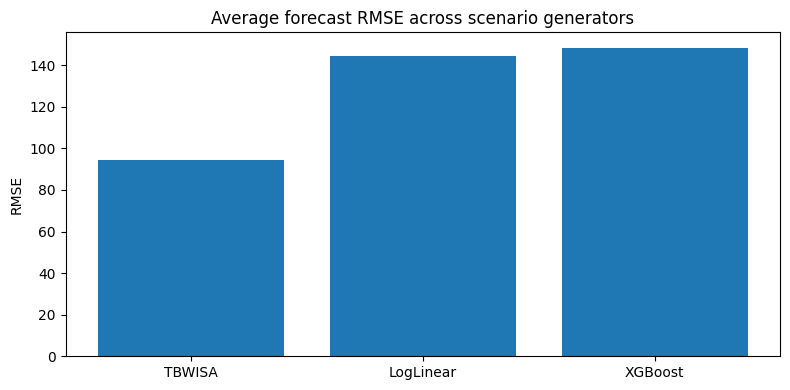

In [6]:
acc_plot = forecast_summary.reset_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(acc_plot['model'], acc_plot['rmse'])
ax.set_title('Average forecast RMSE across scenario generators')
ax.set_ylabel('RMSE')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / 'tbwisa_accuracy_rmse.png', dpi=160, bbox_inches='tight')
plt.show()

## Monotonicity consistency and economic plausibility

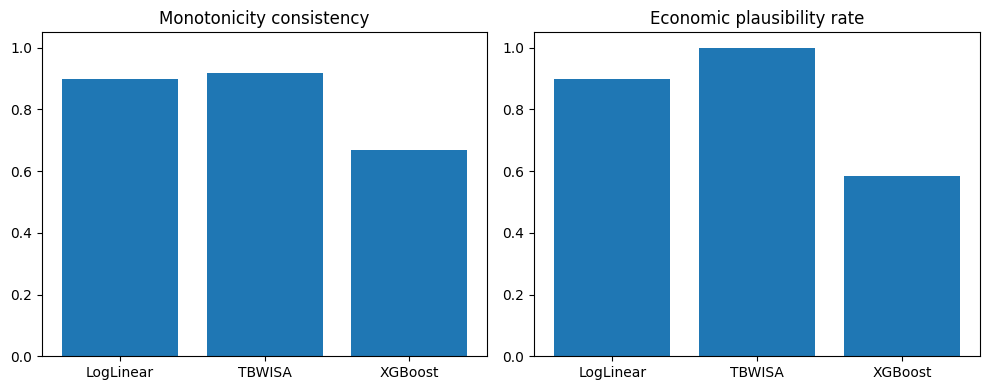

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plaus_plot = plaus_summary.reset_index()
axes[0].bar(plaus_plot['model'], plaus_plot['monotonicity_consistency'])
axes[0].set_title('Monotonicity consistency')
axes[0].set_ylim(0, 1.05)
axes[1].bar(plaus_plot['model'], plaus_plot['economic_plausible'])
axes[1].set_title('Economic plausibility rate')
axes[1].set_ylim(0, 1.05)
for ax in axes:
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / 'tbwisa_monotonicity_plausibility.png', dpi=160, bbox_inches='tight')
plt.show()

## Distribution of implied elasticities across generated scenarios

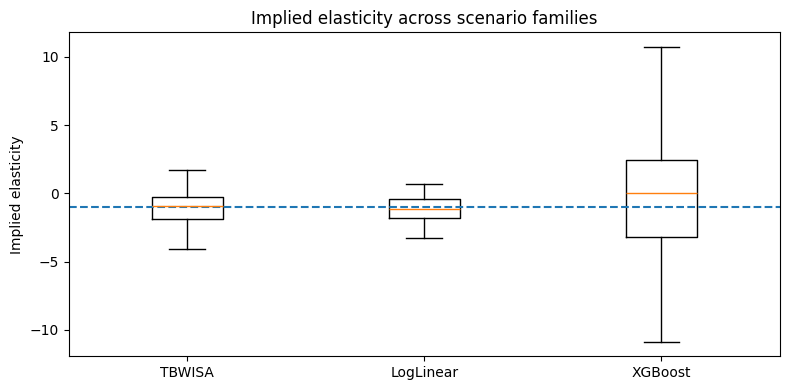

In [8]:
if len(elasticity_df):
    models = elasticity_df['model'].unique().tolist()
    data = [elasticity_df.loc[elasticity_df['model'] == m, 'implied_elasticity'].dropna().values for m in models]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.boxplot(data, labels=models, showfliers=False)
    ax.axhline(-1.0, linestyle='--')
    ax.set_title('Implied elasticity across scenario families')
    ax.set_ylabel('Implied elasticity')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'tbwisa_implied_elasticity_boxplot.png', dpi=160, bbox_inches='tight')
    plt.show()
else:
    print('No implied elasticity rows available.')

## Sensitivity to elasticity-estimation noise (TBWISA only)

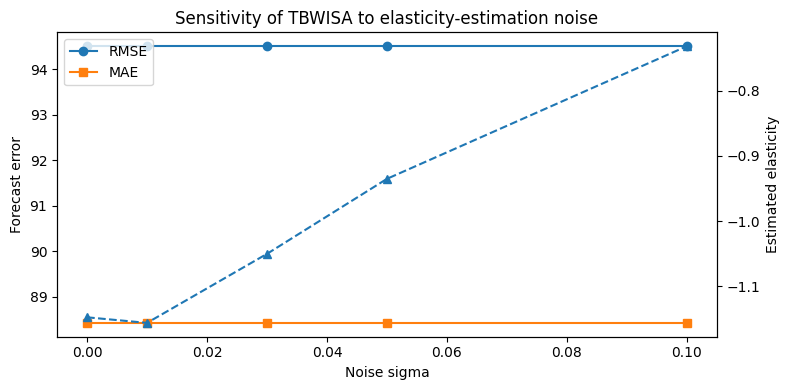

In [9]:
if len(noise_df):
    noise_plot = noise_df.groupby('noise_sigma')[['mae','rmse','elasticity_final']].mean().reset_index()
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(noise_plot['noise_sigma'], noise_plot['rmse'], marker='o', label='RMSE')
    ax1.plot(noise_plot['noise_sigma'], noise_plot['mae'], marker='s', label='MAE')
    ax1.set_xlabel('Noise sigma')
    ax1.set_ylabel('Forecast error')
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(noise_plot['noise_sigma'], noise_plot['elasticity_final'], marker='^', linestyle='--', label='Elasticity')
    ax2.set_ylabel('Estimated elasticity')

    plt.title('Sensitivity of TBWISA to elasticity-estimation noise')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'tbwisa_noise_sensitivity.png', dpi=160, bbox_inches='tight')
    plt.show()
else:
    print('Noise sensitivity results are empty.')

## Stability of optimal windows across scenario generators

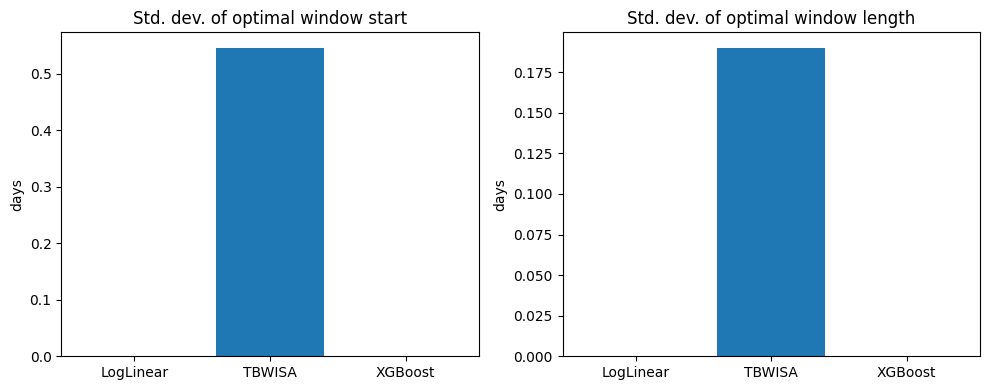

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(tbwisa_window_stability['model'], tbwisa_window_stability['start_offset_std'])
axes[0].set_title('Std. dev. of optimal window start')
axes[0].set_ylabel('days')

axes[1].bar(tbwisa_window_stability['model'], tbwisa_window_stability['window_length_std'])
axes[1].set_title('Std. dev. of optimal window length')
axes[1].set_ylabel('days')

for ax in axes:
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(OUT_DIR / 'tbwisa_window_stability.png', dpi=160, bbox_inches='tight')
plt.show()

## Case-SKU illustration

The first evaluated SKU is kept as an interpretable case example for the thesis figures.

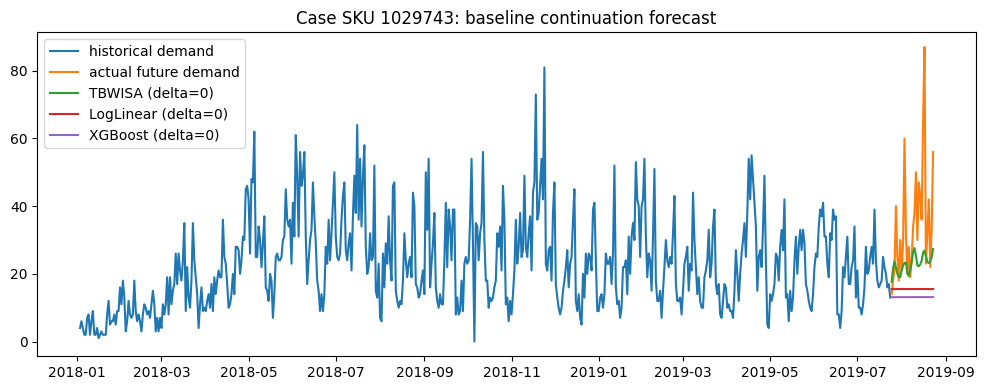

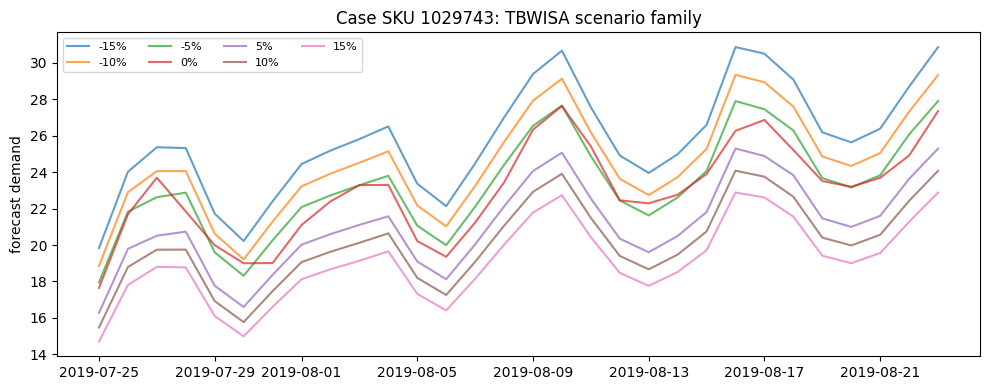

In [11]:
if case_payload is not None:
    sku = case_payload['sku']
    hist_df = case_payload['hist_df']
    fut_df = case_payload['fut_df']
    tb = case_payload['tbwisa_roll']
    ll = case_payload['loglin_roll']
    xg = case_payload['xgb_roll']

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(hist_df[TIME_COL], hist_df[DEMAND_COL], label='historical demand')
    ax.plot(fut_df[TIME_COL], fut_df[DEMAND_COL], label='actual future demand')
    for model_name, payload in [('TBWISA', tb), ('LogLinear', ll), ('XGBoost', xg)]:
        series = payload[0]
        ax.plot(series['future_index'], series['future_demand'], label=f'{model_name} (delta=0)')
    ax.set_title(f'Case SKU {sku}: baseline continuation forecast')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'tbwisa_case_sku_baseline_forecast.png', dpi=160, bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 4))
    for delta, series in tb.items():
        ax.plot(series['future_index'], series['future_demand'], alpha=0.7, label=f'{delta}%')
    ax.set_title(f'Case SKU {sku}: TBWISA scenario family')
    ax.set_ylabel('forecast demand')
    ax.legend(ncol=4, fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'tbwisa_case_sku_scenarios.png', dpi=160, bbox_inches='tight')
    plt.show()
else:
    print('No case payload available.')

## Final exported summaries

In [12]:
print("Files written to:", OUT_DIR.resolve())
for p in sorted(OUT_DIR.glob("*")):
    print("-", p.name)

print("\nPaper-ready tables:")
for name in [
    "tbwisa_forecast_accuracy.csv",
    "tbwisa_noise_sensitivity.csv",
    "tbwisa_plausibility.csv",
    "tbwisa_window_stability.csv",
]:
    print("-", name)

Files written to: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/tbwisa_validation_outputs
- table_d2_tbwisa_elasticity_noise_summary.csv
- tbwisa_accuracy_rmse.png
- tbwisa_case_sku_baseline_forecast.png
- tbwisa_case_sku_scenarios.png
- tbwisa_elasticity_noise_by_sigma_and_sku.csv
- tbwisa_forecast_accuracy.csv
- tbwisa_forecast_accuracy_by_sku.csv
- tbwisa_forecast_accuracy_by_sku_and_generator.csv
- tbwisa_forecast_accuracy_summary.csv
- tbwisa_implied_elasticities.csv
- tbwisa_implied_elasticities_by_sku_and_delta.csv
- tbwisa_implied_elasticity_boxplot.png
- tbwisa_monotonicity_plausibility.png
- tbwisa_noise_sensitivity.csv
- tbwisa_noise_sensitivity.png
- tbwisa_noise_sensitivity_by_sku.csv
- tbwisa_optimal_window_stability_by_sku_and_generator.csv
- tbwisa_plausibility.csv
- tbwisa_plausibility_by_model_and_sku.csv
- tbwisa_plausibility_summary.csv
- tbwisa_plausibility_summary_by_sku.csv
- tbwisa_window_stability.csv
- tb

### Additional exported tables for extended thesis reporting

In [13]:
# Raw extended reporting tables
tbwisa_forecast_accuracy_by_sku_and_generator = forecast_df.copy()
tbwisa_elasticity_noise_by_sigma_and_sku = noise_df.copy() if len(noise_df) else pd.DataFrame()

tbwisa_plausibility_by_model_and_sku = plaus_df.copy()
if len(elasticity_df):
    elasticity_summary_by_sku_model = (
        elasticity_df.groupby(['sku', 'model'], dropna=False)
        .agg(
            avg_implied_elasticity=('implied_elasticity', 'mean'),
            elasticity_dispersion=('implied_elasticity', 'std'),
        )
        .reset_index()
    )
    tbwisa_plausibility_by_model_and_sku = tbwisa_plausibility_by_model_and_sku.merge(
        elasticity_summary_by_sku_model,
        on=['sku', 'model'],
        how='left'
    )

tbwisa_optimal_window_stability_by_sku_and_generator = window_df.copy()
tbwisa_implied_elasticities_by_sku_and_delta = elasticity_df.copy() if len(elasticity_df) else pd.DataFrame()

# Thesis summary tables derived from the extended reporting tables
if len(tbwisa_plausibility_by_model_and_sku):
    tbwisa_plausibility_diagnostics_by_scenario_generator = (
        tbwisa_plausibility_by_model_and_sku.groupby('model')
        .agg(
            monotonicity_consistency=('monotonicity_consistency', 'mean'),
            economic_plausible_rate=('economic_plausible', 'mean'),
            avg_price_demand_corr=('corr_price_demand', 'mean'),
            avg_implied_elasticity=('avg_implied_elasticity', 'mean'),
            elasticity_dispersion=('elasticity_dispersion', 'mean'),
        )
        .reset_index()
    )
else:
    tbwisa_plausibility_diagnostics_by_scenario_generator = pd.DataFrame(columns=[
        'model',
        'monotonicity_consistency',
        'economic_plausible_rate',
        'avg_price_demand_corr',
        'avg_implied_elasticity',
        'elasticity_dispersion',
    ])

if len(tbwisa_plausibility_by_model_and_sku):
    tbwisa_plausibility_diagnostics_by_sku_and_scenario_generator = (
        tbwisa_plausibility_by_model_and_sku
        .rename(columns={'corr_price_demand': 'price_demand_corr'})
        [[
            'sku',
            'model',
            'monotonicity_consistency',
            'economic_plausible',
            'price_demand_corr',
            'avg_implied_elasticity',
            'elasticity_dispersion',
        ]]
        .sort_values(['sku', 'model'])
        .reset_index(drop=True)
    )
else:
    tbwisa_plausibility_diagnostics_by_sku_and_scenario_generator = pd.DataFrame(columns=[
        'sku',
        'model',
        'monotonicity_consistency',
        'economic_plausible',
        'price_demand_corr',
        'avg_implied_elasticity',
        'elasticity_dispersion',
    ])

if len(tbwisa_elasticity_noise_by_sigma_and_sku):
    tbwisa_elasticity_noise_sensitivity_summary = (
        tbwisa_elasticity_noise_by_sigma_and_sku.groupby('noise_sigma', as_index=False)
        .agg(
            avg_elasticity_raw=('elasticity_raw', 'mean'),
            avg_elasticity_final=('elasticity_final', 'mean'),
            avg_mae=('mae', 'mean'),
            avg_rmse=('rmse', 'mean'),
        )
        .sort_values('noise_sigma')
        .reset_index(drop=True)
    )
else:
    tbwisa_elasticity_noise_sensitivity_summary = pd.DataFrame(columns=[
        'noise_sigma',
        'avg_elasticity_raw',
        'avg_elasticity_final',
        'avg_mae',
        'avg_rmse',
    ])

# Store all extended thesis reporting tables using the same pattern
tbwisa_extended_reporting_tables = [
    (
        'TBWISA forecast accuracy by SKU and scenario generator',
        'tbwisa_forecast_accuracy_by_sku_and_generator.csv',
        tbwisa_forecast_accuracy_by_sku_and_generator,
    ),
    (
        'TBWISA elasticity-noise diagnostics by sigma and SKU',
        'tbwisa_elasticity_noise_by_sigma_and_sku.csv',
        tbwisa_elasticity_noise_by_sigma_and_sku,
    ),
    (
        'TBWISA plausibility diagnostics by model and SKU',
        'tbwisa_plausibility_by_model_and_sku.csv',
        tbwisa_plausibility_by_model_and_sku,
    ),
    (
        'TBWISA optimal window stability by SKU and scenario generator',
        'tbwisa_optimal_window_stability_by_sku_and_generator.csv',
        tbwisa_optimal_window_stability_by_sku_and_generator,
    ),
    (
        'TBWISA implied elasticities by SKU and delta',
        'tbwisa_implied_elasticities_by_sku_and_delta.csv',
        tbwisa_implied_elasticities_by_sku_and_delta,
    ),
    (
        'TBWISA plausibility diagnostics by scenario generator',
        'tbwisa_plausibility_diagnostics_by_scenario_generator.csv',
        tbwisa_plausibility_diagnostics_by_scenario_generator,
    ),
    (
        'TBWISA plausibility diagnostics by SKU and scenario generator',
        'tbwisa_plausibility_diagnostics_by_sku_and_scenario_generator.csv',
        tbwisa_plausibility_diagnostics_by_sku_and_scenario_generator,
    ),
    (
        'TBWISA elasticity-noise sensitivity summary',
        'tbwisa_elasticity_noise_sensitivity_summary.csv',
        tbwisa_elasticity_noise_sensitivity_summary,
    ),
]

for _, file_name, table in tbwisa_extended_reporting_tables:
    table.to_csv(OUT_DIR / file_name, index=False)

print('Additional TBWISA tables written:')
for _, file_name, _ in tbwisa_extended_reporting_tables:
    print('-', file_name)

Additional TBWISA tables written:
- tbwisa_forecast_accuracy_by_sku_and_generator.csv
- tbwisa_elasticity_noise_by_sigma_and_sku.csv
- tbwisa_plausibility_by_model_and_sku.csv
- tbwisa_optimal_window_stability_by_sku_and_generator.csv
- tbwisa_implied_elasticities_by_sku_and_delta.csv
- tbwisa_plausibility_diagnostics_by_scenario_generator.csv
- tbwisa_plausibility_diagnostics_by_sku_and_scenario_generator.csv
- tbwisa_elasticity_noise_sensitivity_summary.csv


In [15]:
# Display additional TBWISA thesis reporting tables

for table_name, _, table in tbwisa_extended_reporting_tables:
    print(f'\n{table_name}')
    display(table)


TBWISA forecast accuracy by SKU and scenario generator


,sku,model,mae,rmse,mape
0,1029743,TBWISA,12.765426,18.697047,2.916721e-01
1,1029743,LogLinear,19.158082,24.939724,4.701023e-01
2,1029743,XGBoost,21.441645,26.805240,5.455068e-01
3,981760,TBWISA,6.984183,8.618792,1.190675e+00
4,981760,LogLinear,7.063848,9.246745,1.070022e+00
...,...,...,...,...,...
175,1404121,LogLinear,7970.687695,8434.409320,7.336568e+12
176,1404121,XGBoost,8166.651139,8656.578433,7.541618e+12
177,9245413,TBWISA,5.613495,7.146691,3.502320e+09
178,9245413,LogLinear,8.038740,8.559554,5.964960e+09



TBWISA elasticity-noise diagnostics by sigma and SKU


,sku,noise_sigma,elasticity_raw,elasticity_final,r2,mae,rmse,mape
0,1029743,0.00,-0.979247,-0.979247,0.582458,12.765426,18.697047,2.916721e-01
1,1029743,0.01,-0.872811,-0.872811,0.591274,12.765426,18.697047,2.916721e-01
2,1029743,0.03,-0.720739,-0.720739,0.585027,12.765426,18.697047,2.916721e-01
3,1029743,0.05,-0.698625,-0.698625,0.584539,12.765426,18.697047,2.916721e-01
4,1029743,0.10,-0.358856,-0.358856,0.571516,12.765426,18.697047,2.916721e-01
...,...,...,...,...,...,...,...,...
295,9245413,0.00,0.000000,-0.050000,NaN,5.613495,7.146691,3.502320e+09
296,9245413,0.01,0.000000,-0.050000,NaN,5.613495,7.146691,3.502320e+09
297,9245413,0.03,0.000000,-0.050000,NaN,5.613495,7.146691,3.502320e+09
298,9245413,0.05,0.000000,-0.050000,NaN,5.613495,7.146691,3.502320e+09



TBWISA plausibility diagnostics by model and SKU


...

,model,monotonicity_consistency,economic_plausible_rate,avg_price_demand_corr,avg_implied_elasticity,elasticity_dispersion
0,LogLinear,0.900000,0.900000,-0.794846,-1.159207,0.001085
1,TBWISA,0.919444,1.000000,-0.870591,-1.157874,0.458580
2,XGBoost,0.669444,0.583333,-0.131891,-0.843738,6.519798



TBWISA plausibility diagnostics by SKU and scenario generator


,sku,model,monotonicity_consistency,economic_plausible,price_demand_corr,avg_implied_elasticity,elasticity_dispersion
0,1004906,LogLinear,1.000000,1.0,-0.998622,-0.202614,0.000013
1,1004906,TBWISA,1.000000,1.0,-0.993372,-1.338453,0.767056
2,1004906,XGBoost,0.833333,1.0,-0.014169,1.603131,4.388663
3,1006184,LogLinear,1.000000,1.0,-0.992689,-1.756721,0.002251
4,1006184,TBWISA,1.000000,1.0,-0.996098,-1.873315,0.723891
...,...,...,...,...,...,...,...
175,995965,TBWISA,1.000000,1.0,-0.995799,-2.081659,0.461223
176,995965,XGBoost,0.666667,1.0,-0.608968,-4.724699,7.665671
177,999270,LogLinear,1.000000,1.0,-0.992334,-1.814174,0.003380
178,999270,TBWISA,1.000000,1.0,-0.990868,-2.448248,1.559073



TBWISA elasticity-noise sensitivity summary


,noise_sigma,avg_elasticity_raw,avg_elasticity_final,avg_mae,avg_rmse
0,0.00,-0.972774,-1.147428,88.422348,94.5066
1,0.01,-1.072796,-1.155984,88.422348,94.5066
2,0.03,-0.982364,-1.050086,88.422348,94.5066
3,0.05,-0.889906,-0.935039,88.422348,94.5066
4,0.10,-0.693722,-0.731621,88.422348,94.5066
